# Use case — customer segmentation (mixed RFM + categorical)

A marketing team wants **actionable segments** from a customer table that is part numeric
(RFM: recency, frequency, monetary) and part categorical (region, device, acquisition channel).
Plain k-means throws the categorical signal away. **k-prototypes** (`KPrototypes`) clusters both at
once — each segment gets a numeric **mean** *and* a categorical **mode** — so the output is a
ready-to-use persona table with a recommended action per segment.

```bash
pip install betula-cluster matplotlib seaborn pandas scikit-learn
```

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from betula_cluster import KPrototypes, fit_predict

sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold"})
rng = np.random.default_rng(7)

REGIONS = ["EU", "US", "APAC", "LATAM"]
DEVICES = ["mobile", "desktop", "tablet"]
CHANNELS = ["organic", "paid", "referral", "social"]


def ari(a, b):
    a, b = np.asarray(a), np.asarray(b)
    cont = pd.crosstab(a, b).to_numpy().astype(float)
    comb = lambda m: (m * (m - 1) / 2).sum()
    s, sa, sb, t = comb(cont), comb(cont.sum(1)), comb(cont.sum(0)), comb(np.array([len(a)]))
    exp = sa * sb / t
    return float((s - exp) / (0.5 * (sa + sb) - exp))

## A customer base with four latent segments

The catch: **two segments are nearly identical in RFM** — high-value, recent, frequent — and differ
*only* in how they were acquired (referral+mobile vs paid+desktop). RFM alone cannot tell them apart;
the categorical signal can. The other two (newcomers, at-risk) are numerically distinct.

In [2]:
# recency_days↓ better, frequency↑, monetary↑;  categorical given as probability vectors
segments = [
    # ↓ same RFM as the next one — only region/device/channel separate them
    {"name": "referral champions", "rec": (25, 10), "freq": (30, 6), "mon": (1700, 300), "region": [.7, .15, .1, .05], "device": [.8, .15, .05], "channel": [.05, .05, .85, .05]},
    {"name": "paid champions", "rec": (25, 10), "freq": (30, 6), "mon": (1700, 300), "region": [.1, .7, .15, .05], "device": [.1, .8, .1], "channel": [.05, .85, .05, .05]},
    {"name": "newcomers", "rec": (18, 7), "freq": (3, 1), "mon": (120, 50), "region": [.2, .2, .3, .3], "device": [.6, .2, .2], "channel": [.1, .2, .1, .6]},
    {"name": "at-risk", "rec": (150, 35), "freq": (9, 3), "mon": (900, 300), "region": [.25, .3, .2, .25], "device": [.3, .6, .1], "channel": [.2, .55, .15, .1]},
]
rows, truth = [], []
for s, seg in enumerate(segments):
    for _ in range(500):
        rows.append(
            {
                "recency_days": max(1.0, rng.normal(*seg["rec"])),
                "frequency": max(1.0, rng.normal(*seg["freq"])),
                "monetary": max(10.0, rng.normal(*seg["mon"])),
                "region": rng.choice(4, p=seg["region"]),
                "device": rng.choice(3, p=seg["device"]),
                "channel": rng.choice(4, p=seg["channel"]),
            }
        )
        truth.append(s)
df = pd.DataFrame(rows)
truth = np.array(truth)
shown = df.copy()
for col, names in [("region", REGIONS), ("device", DEVICES), ("channel", CHANNELS)]:
    shown[col] = shown[col].map(dict(enumerate(names)))
shown.head()

,recency_days,frequency,monetary,region,device,channel
0,25.012302,31.792473,1617.758643,EU,mobile,referral
1,25.601436,38.041291,1552.338044,EU,mobile,referral
2,26.054142,24.417192,1691.224453,EU,tablet,referral
3,5.987773,22.262774,1147.479489,EU,mobile,organic
4,26.567511,28.878414,944.972087,APAC,mobile,referral


## Segment with `KPrototypes`

Columns 3–5 (`region`, `device`, `channel`) are categorical integer codes; columns 0–2 are numeric
RFM. **Standardize the numeric columns first** — otherwise `monetary` (~1000s) dwarfs `frequency`
(~10s) *and* the categorical mismatch term, and the result collapses to a pure monetary split. After
z-scoring, `gamma` (the numeric↔categorical trade-off, Huang's heuristic by default) is balanced.

In [3]:
num_cols = ["recency_days", "frequency", "monetary"]
cat_cols = ["region", "device", "channel"]
num = df[num_cols].to_numpy(np.float64)
Xnum_z = (num - num.mean(0)) / num.std(0)  # standardize so no feature (monetary!) dominates
X = np.column_stack([Xnum_z, df[cat_cols].to_numpy(np.float64)])  # categorical kept as integer codes
kp = KPrototypes(n_clusters=4, categorical=[3, 4, 5], seed=1)
labels = np.asarray(kp.fit_predict(X))
print(f"segments: {kp.n_clusters_}   ARI vs latent truth: {ari(labels, truth):.3f}")

segments: 4   ARI vs latent truth: 0.894


## The persona table — the actual deliverable

Real-unit RFM means (per segment) + the categorical modes (`cluster_modes_` — k-prototypes' built-in
categorical centroid), turned into a named persona and a recommended action by simple RFM rules. The
two champion sub-segments share an RFM profile but get **different actions** from their channel mode.

In [4]:
k = kp.n_clusters_
prof_num = df.groupby(labels)[num_cols].mean().reindex(range(k))  # real units, per segment
sizes = df.groupby(labels).size().reindex(range(k)).fillna(0).astype(int)
modes = kp.cluster_modes_  # (k, 3): region, device, channel codes — categorical centroids
med_rec, med_freq, med_mon = prof_num.median()


def persona(rec, freq, mon, channel):
    if rec >= 2 * med_rec:  # long since last purchase
        return "At-risk", "Win-back campaign, personal outreach"
    if freq <= 0.5 * med_freq and mon <= 0.5 * med_mon:
        return "Newcomers", f"Onboarding via {channel}, 2nd-purchase nudge"
    if mon >= med_mon and freq >= med_freq:  # two champion sub-segments differ only by channel
        return "Champions", f"VIP perks; double down on {channel} acquisition"
    return "Loyal regulars", "Loyalty program, cross-sell"


profile = pd.DataFrame(
    {
        "size": sizes.to_numpy(),
        "recency_days": prof_num["recency_days"].round(0).to_numpy(),
        "frequency": prof_num["frequency"].round(1).to_numpy(),
        "monetary": prof_num["monetary"].round(0).to_numpy(),
        "region": [REGIONS[modes[c, 0]] for c in range(k)],
        "device": [DEVICES[modes[c, 1]] for c in range(k)],
        "channel": [CHANNELS[modes[c, 2]] for c in range(k)],
    }
)
profile[["persona", "recommended_action"]] = [
    persona(profile.loc[c, "recency_days"], profile.loc[c, "frequency"], profile.loc[c, "monetary"], profile.loc[c, "channel"])
    for c in range(k)
]
profile

,size,recency_days,frequency,monetary,region,device,channel,persona,recommended_action
0,506,24.0,29.5,1714.0,US,desktop,paid,Champions,VIP perks; double down on paid acquisition
1,491,150.0,9.4,892.0,US,desktop,paid,At-risk,"Win-back campaign, personal outreach"
2,509,18.0,3.1,132.0,APAC,mobile,social,Newcomers,"Onboarding via social, 2nd-purchase nudge"
3,494,25.0,30.3,1685.0,EU,mobile,referral,Champions,VIP perks; double down on referral acquisition


## Visualize — RFM split + channel mix + segment sizes

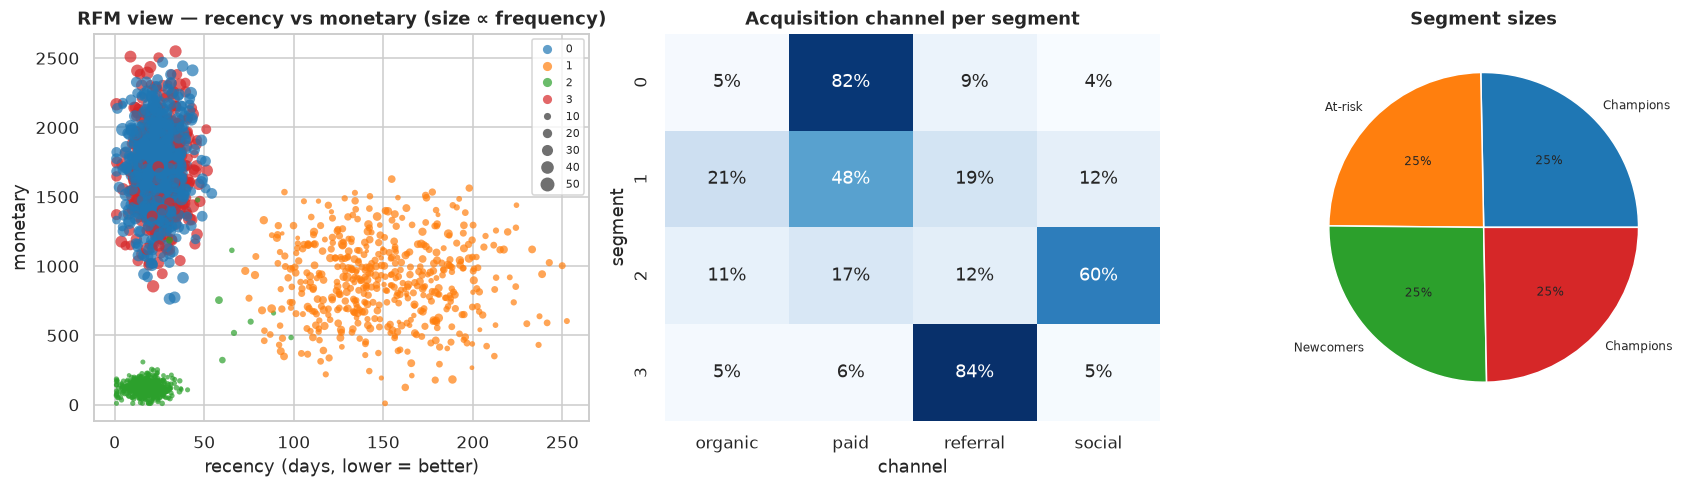

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
sns.scatterplot(x=df["recency_days"], y=df["monetary"], hue=labels, size=df["frequency"], palette="tab10", sizes=(8, 90), linewidth=0, alpha=0.7, ax=axes[0], legend="brief")
axes[0].set(title="RFM view — recency vs monetary (size ∝ frequency)", xlabel="recency (days, lower = better)", ylabel="monetary")
axes[0].legend(fontsize=7, loc="upper right")

comp = pd.crosstab(labels, df["channel"].map(dict(enumerate(CHANNELS))), normalize="index").reindex(columns=CHANNELS).fillna(0.0)
sns.heatmap(comp, annot=True, fmt=".0%", cmap="Blues", cbar=False, ax=axes[1])
axes[1].set(title="Acquisition channel per segment", xlabel="channel", ylabel="segment")

sizes = profile.set_index("persona")["size"]
axes[2].pie(sizes, labels=sizes.index, autopct="%1.0f%%", colors=sns.color_palette("tab10", len(sizes)), textprops={"fontsize": 8})
axes[2].set_title("Segment sizes")
plt.tight_layout()
plt.show()

## Why mixed beats numeric-only

Dropping `region` / `device` / `channel` and running k-means on RFM alone blurs segments that overlap
numerically but differ in behaviour — k-prototypes recovers the true segments better because it uses
both signals at once.

In [6]:
num_only = fit_predict(Xnum_z, 4, method="kmeans", seed=1)  # same standardized RFM, for a fair test
pd.DataFrame(
    {
        "method": ["k-means (RFM only)", "k-prototypes (RFM + categorical)"],
        "ARI vs true segments": [round(ari(num_only, truth), 3), round(ari(labels, truth), 3)],
    }
)

,method,ARI vs true segments
0,k-means (RFM only),0.657
1,k-prototypes (RFM + categorical),0.894
